### В данном файле:
1) вычитываем биткойн-датасет и сохраняем в original.csv
2) получаем для этого датасета отчет. Наша цель понять, есть ли в датасете n/a, дубликаты, категориальные признаки
3) ориентируясь на результатах base_report, заполняем n/a через функцию интерполяции, а дату за мегняем на timestamp
4) выбираем признаки, с которыми будем работать далее
5) Визуализируем:
    * важность признаков
    * диаграмму корреляции
6) Для итогового набора признаков строим графики:
    * ящики с усами
    * аномалии для volume, target_return
7) Сохраняем сокращенный датасет в reduced.csv

In [ ]:
%pip install colorama pandas matplotlib kagglehub jinja2 scikit-learn seaborn lightgbm xgboost catboost optuna

In [ ]:
%pip install --upgrade nbformat ipykernel

In [ ]:
%pip install --upgrade jupyter ipywidgets

In [ ]:
# import kagglehub

# path = kagglehub.dataset_download("purnamaridzkynugraha/bitcoin-historical-data")

# print("Path to dataset files:", path)

#### Columns description:
* <font color="coral">date : Дата начала торгов</font>
* adj close : Ежедневные данные о цене OHLCV для BTC-USD
* <font color="coral">close : Ежедневные данные о цене OHL_C_V для BTC-USD </font>
* <font color="coral">high : Ежедневные данные о цене O_H_LCV для BTC-USD </font>
* <font color="coral">low : Ежедневные данные о цене OH_L_CV для BTC-USD</font>
* <font color="coral">open : Ежедневные данные о цене _O_HLCV для BTC-USD</font>
* <font color="coral">volume : Величина ежедневного объема торгов</font>
* sp500_close : Цена закрытия индекса S&P 500 (показатель состояния фондового рынка США)
* gold_close : Цена фьючерсов на золото (индикатор активов-убежищ)
* dxy_close : Индекс доллара США (показатель силы фиатной валюты)
* fng_score : Индекс страха и жадности перед криптовалютами (0-100) : 
    * 0-25 (Крайний страх): Признак рыночной паники (потенциальная возможность для покупки)
    * 75-100 (Крайняя жадность): Признак рыночного оптимизма (потенциальная коррекция)
* google_trends_score : Относительный объем поисковых запросов по ключевому слову "Биткойн" (показатель ажиотажа/интереса со стороны розничных инвесторов)
* btc_return : Ежедневная простая процентная доходность
* btc_log_return : Ежедневная логарифмическая доходность (предпочтительно для моделей машинного обучения)
* sp500_return : Ежедневная доходность макроактивов (фондовый рынок США)
* gold_return : Ежедневная доходность макроактивов (индикатор активов-убежищ) 
* dxy_return : Ежедневная доходность макроактивов (показатель силы фиатной валюты)
* btc_vol_7d : Скользящая волатильность (стандартное отклонение) за 7 дней
* btc_vol_14d : Скользящая волатильность (стандартное отклонение) за 14 дней
-----------------------------------------------------------------------------
* <font color="coral">target_return: Рост цены биткоина за следующие 14 дней.</font>
* target_direction: Бинарная классификационная метка ( 1 = Вверх, 0 = Вниз/Плоско) на следующие 14 дней

In [ ]:
import pandas as pd

from private.utils import (
    base_report,
    correlogram,
    feature_importance,
    load_bitcoin_data,
)

df_original = load_bitcoin_data()

base_report(df_original, '')
print(f"Целевая функция Target_return min/max : {df_original['target_return'].min():.3f} / {df_original['target_return'].max():.3f}")

rows × cols,n/a,duplicates,0-columns,types
1826×22,46,0,0,"float64(19), int64(2), str(1)"


not numeric: ['date']
n/a:


google_trends_score,btc_return,btc_log_return,sp500_return,gold_return,dxy_return,btc_vol_7d,btc_vol_14d,target_return
6,1,1,1,1,1,7,14,14


Целевая функция Target_return min/max : -0.403 / 0.479


#### Выбираем признаки
1) выберем в качестве признаков  <font color="coral">date, open, high, low, close, volume,</font> а в качестве целевой функции <font color="coral">target_return</font>, вычисляемая по формуле:

![target_return в нашем датасете в долях, а не процентах](.\data\pictures\formula.png)

2) Диапазон целевой функции, как видно выше: -0.403 / 0.479
3) Преобразуем data в datatime
4) Заполним N/a используя интерполяцию

In [2]:
df_original["date"] = pd.to_datetime(df_original["date"]).astype(int) // 10**9

df_work = df_original[['date', 'open', 'high', 'low', 'close', 'volume', 'target_return']]
for name in df_work.columns[df_work.isna().any()].tolist():
    df_work[name] = df_work[name].interpolate(limit_direction='both')

base_report(df_work, '')

rows × cols,n/a,duplicates,0-columns,types
1826×7,0,0,0,"float64(5), int64(2)"


#### Визуализация :
1) оценить feature_importamce
2) матрица взаимной корреляции
3) гистограммы, графики, 'ящики с усами'  

#### Визуализация: feature_importance

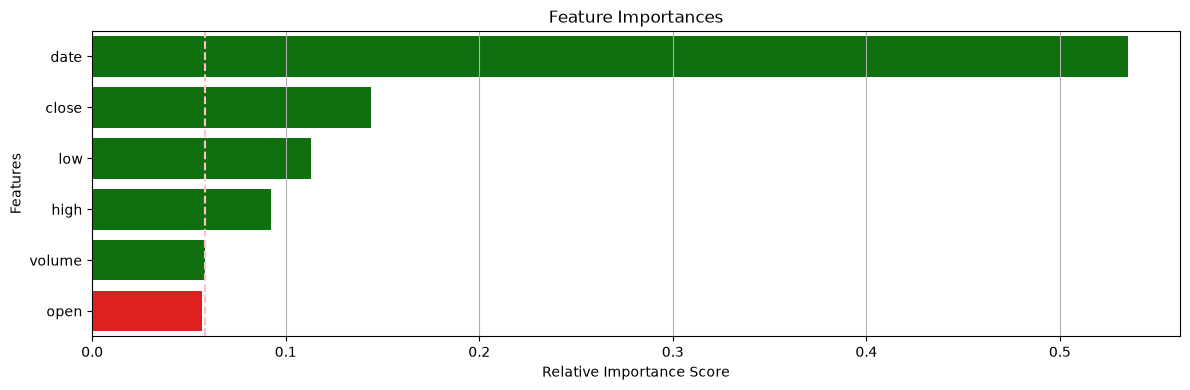

In [3]:
feature_importance(
    X=df_work.drop(columns=['target_return']),
    y=df_work['target_return']
)

#### Вывод:
* нет признаков с нулевой значимостью, поэтому не будем исключать "красные" признаки из датасета

#### Диаграмма корреляции:

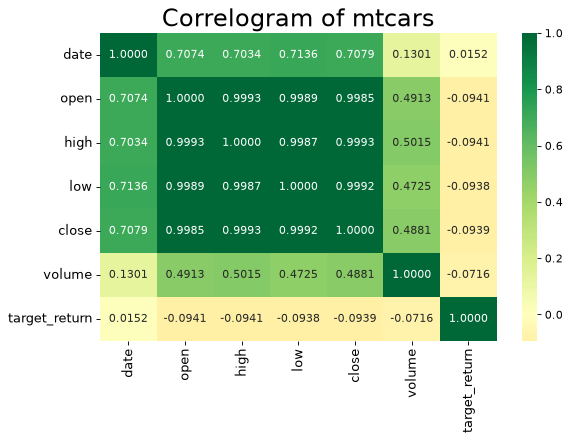

In [4]:
correlogram(df_work)

#### TODO:
1) общий ргафик ящиков с усами
2) подстчет аномалий
3) график целевой функции с аномалиями

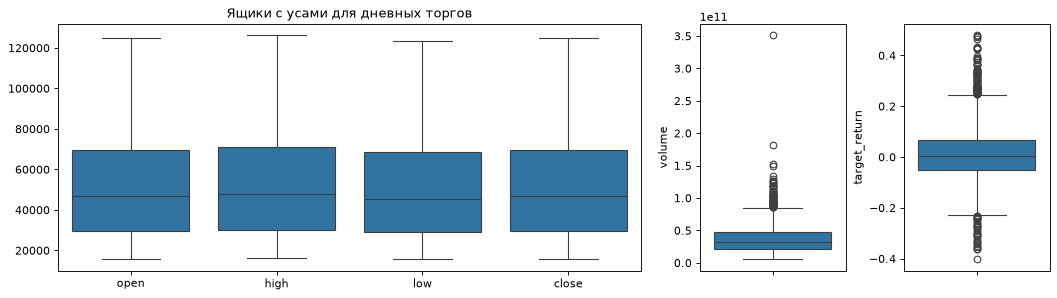

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

fig = plt.figure(figsize=(16, 4), dpi=80)
grid = plt.GridSpec(1, 3, width_ratios=[4, 1, 1])

ax_1 = fig.add_subplot(grid[0, 0])
ax_2 = fig.add_subplot(grid[0, 1])
ax_3 = fig.add_subplot(grid[0, 2])

sns.boxplot(data=df_work[['open', 'high', 'low', 'close']], ax=ax_1, color="#1f77b4")
sns.boxplot(y=df_work["volume"], ax=ax_2, orient="v")
sns.boxplot(y=df_work['target_return'], ax=ax_3, orient="v")

ax_1.set_title('Ящики с усами для дневных торгов')
plt.show()

#### Получаем индексы выбросов:

In [6]:
from private.utils import outliers

out_volume = outliers(df_work, 'volume')
out_target_return = outliers(df_work, 'target_return')

out_volume_indexes = set(out_volume.index)
out_target_return_indexes = set(out_target_return.index)

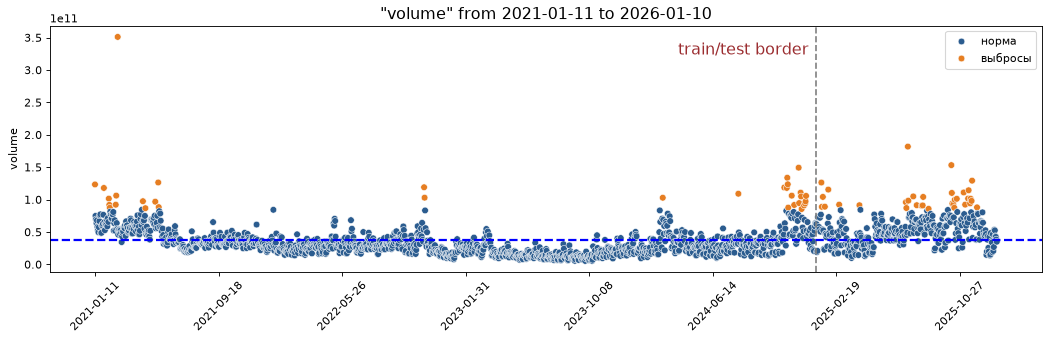

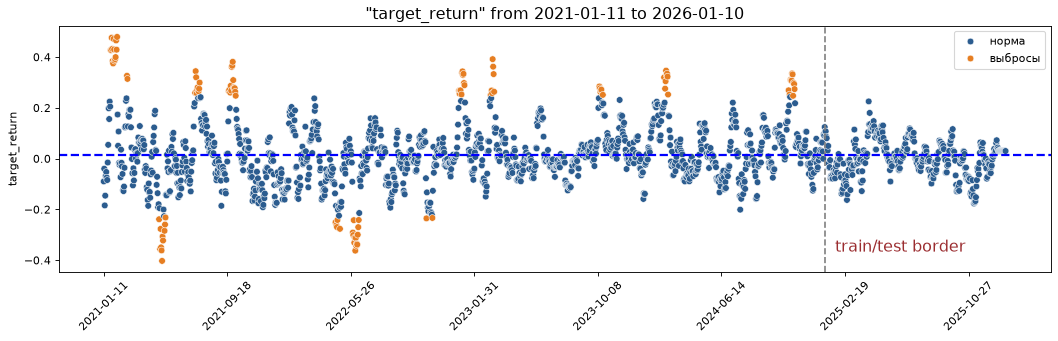

In [7]:
from private.utils import outliers_plot

outliers_plot(df_work, 'volume', out_volume_indexes, True)
outliers_plot(df_work, 'target_return', out_target_return_indexes, False)

#### Сохраним в reduced.csv данные, для которых будем изучать регрессию 

In [9]:
df_work.to_csv("./data/reduced.csv", index=False)
base_report(df_work, "target_return")

rows × cols,n/a,duplicates,0-columns,types
1826×7,0,0,0,"float64(5), int64(2)"
